# Sampling vs. contracting the same MPS

Two ways to turn a QAOA circuit into an energy, both running on the *same* Qiskit Aer
matrix-product-state backend:

| | contraction | `MPSSampleEvaluator` |
|---|---|---|
| how the energy is obtained | contract $\langle\psi\vert H_C\vert\psi\rangle$ on the MPS, term by term | draw `shots` bit strings from the MPS and average $H_C(x)$ |
| primitive | `qiskit_aer.primitives.EstimatorV2` with `default_precision = 0` | `BackendSamplerV2` |
| cost driver | one contraction per Pauli term of $H_C$ | one circuit, then a classical pass over the samples |
| error | MPS truncation only | MPS truncation **and** shot noise |

This notebook tests whether using sampling with a sparse representation of the cost hamiltonian and classical evaluation of the samples outperforms contraction with the full cost hamiltonian 

In [39]:
from time import perf_counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2

from qaoa_training_pipeline.evaluation import EfficientDepthOneEvaluator, MPSSampleEvaluator
from qaoa_training_pipeline.evaluation.aer_interface import AerEvaluator
from qaoa_training_pipeline.training.parameter_scanner import DepthOneScanTrainer
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator

In [40]:
# --- configuration of the benchmark -------------------------------------------------
SEED = 42

NUM_QUBITS = 16  # number of nodes of the fully connected cost graph
MEAN_DEGREE = 3  # mean degree of the sparsified ansatz
BOND_DIM = 64  # chi of the shared Aer MPS backend
TRUNCATION = 1e-16  # MPS truncation threshold of the shared backend
SHOTS = 4000  # shots of MPSSampleEvaluator
MAX_THREADS = 10  # Aer threads, identical for both
REPEATS = 4  # timed repetitions per data point
SCAN_POINTS = 15  # grid resolution of the depth-one scan

# Cheaper settings for the parameter sweeps further down.
SWEEP_SCAN_POINTS = 7
SWEEP_BOND_DIM = 32
SWEEP_SHOTS = 4000
DENSITY_QUBITS = 24  # register used for the cost-operator density sweep

### Constructing the evaluators
Construct the evaluators with comparable backends. MPSSampleEvaluator works with Aer, so for contraction need to use AerEstimator. 

In [41]:
def make_contraction_evaluator(bond_dim=BOND_DIM, threads=MAX_THREADS) -> AerEvaluator:
    """Exact <psi|H_C|psi> contracted on the Aer MPS. default_precision set to 0 gives no shot noise, i.e. exact contraction not based on samples"""
    estimator = AerEstimatorV2(
        options={
            "backend_options": {
                "method": "matrix_product_state",
                "matrix_product_state_max_bond_dimension": bond_dim,
                "matrix_product_state_truncation_threshold": TRUNCATION,
                "max_parallel_threads": threads,
            },
            "default_precision": 0.0,
        }
    )

    return AerEvaluator(estimator)


def make_sample_evaluator(
    bond_dim=BOND_DIM, shots=SHOTS, threads=MAX_THREADS
) -> MPSSampleEvaluator:
    """Sampling from the same backend, with the same bond dimension and thread count."""
    return MPSSampleEvaluator(chi=bond_dim, shots=shots, max_parallel_threads=threads)

## Construct a fully connected cost operator

The cost operator is the complete graph $K_n$ with random Gaussian couplings.

In [42]:
def weighted_complete_graph(num_nodes: int, seed: int = SEED) -> nx.Graph:
    """Complete graph with i.i.d. standard normal edge weights."""
    generator = np.random.default_rng(seed)
    graph = nx.Graph()
    graph.add_nodes_from(range(num_nodes))
    for node1 in range(num_nodes):
        for node2 in range(node1 + 1, num_nodes):
            graph.add_edge(node1, node2, weight=float(generator.normal()))

    return graph


cost_graph = weighted_complete_graph(NUM_QUBITS)
cost_op = graph_to_operator(cost_graph)

print(f"Number of qubits: {cost_op.num_qubits}")
print(f"Pauli terms: {len(cost_op)}")

Number of qubits: 16
Pauli terms: 120


### Helper functions

In [ ]:
# Generate a subgraph with edges that can be implemented with less than num_swaps SWAPS
def generate_subgraph_swap_distance(swap_strategy, graph, num_swaps):
    A = nx.to_numpy_array(graph, weight="weight")
    mask = (swap_strategy.distance_matrix >= 0) & (swap_strategy.distance_matrix <= num_swaps)

    sub_graph = nx.from_numpy_array(A * mask)

    return sub_graph


# Create the ansatz operator as SparsePauliOp
def ansatz_operator(sub_graph: nx.Graph):
    """The sparsified ansatz as a SparsePauliOp -- what both MPS evaluators consume."""
    return graph_to_operator(sub_graph)


# Create the ansatz operator as QuantumCircuit
def ansatz_circuit(sub_graph: nx.Graph) -> QuantumCircuit:
    """The same ansatz as an Rzz network -- what EfficientDepthOneEvaluator consumes."""
    gamma = Parameter("gamma")
    circuit = QuantumCircuit(sub_graph.number_of_nodes())
    for node1, node2, data in sub_graph.edges(data=True):
        circuit.rzz(2 * data.get("weight", 1.0) * gamma, node1, node2)

    return circuit

### Test that we can generate a cost operator for a dense graph and a sparse ansatz

In [ ]:
swap_strategy = SwapStrategy.from_line(list(range(NUM_QUBITS)))
ansatz_graph = generate_subgraph_swap_distance(swap_strategy, cost_graph, NUM_QUBITS / 10)
edge_ratio = ansatz_graph.number_of_edges() / cost_graph.number_of_edges()

print(f"cost operator : {cost_graph.number_of_edges()} edges (fully connected)")
print(
    f"ansatz        : {ansatz_graph.number_of_edges()} edges ({edge_ratio:.1%} of the cost operator)"
)
print(f"mean degree   : {2 * ansatz_graph.number_of_edges() / NUM_QUBITS:.2f}")

cost operator : 120 edges (fully connected)
ansatz        : 22 edges (18.3% of the cost operator)
mean degree   : 2.75


### Generate a figure to compare the full cost graph with the sparsified version

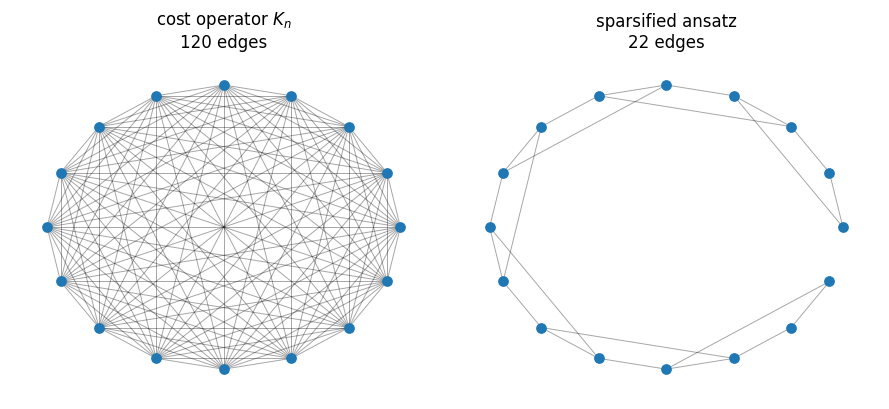

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
positions = nx.circular_layout(cost_graph)

for axis, (title, graph) in zip(
    axes, [("cost operator $K_n$", cost_graph), ("sparsified ansatz", ansatz_graph)]
):
    nx.draw_networkx_edges(graph, positions, ax=axis, alpha=0.35, width=0.7)
    nx.draw_networkx_nodes(graph, positions, ax=axis, node_size=45, node_color="tab:blue")
    axis.set_title(f"{title}\n{graph.number_of_edges()} edges")
    axis.set_axis_off()

fig.tight_layout()
plt.show()

### Get near-optimal parameters at depth 1
The comparison will be performed with respect to the parameters at depth 1 found using DepthOneScanTrainer and EfficientDepthOneEvaluator

In [46]:
def scan_angles(operator, sub_graph, num_points=SCAN_POINTS):
    """Depth-one scan with the exact evaluator. Returns (angles, result, trainer)."""
    trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator(), num_points=num_points)
    result = trainer.provide_params(operator, ansatz_circuit=ansatz_circuit(sub_graph))

    return list(result["optimized_params"]), result, trainer


start = perf_counter()
angles, scan_result, scanner = scan_angles(cost_op, ansatz_graph)
scan_time = perf_counter() - start

beta, gamma = angles
print(
    f"Scan over {SCAN_POINTS}x{SCAN_POINTS} points took {scan_time:.2f} s "
    f"({np.mean(scan_result['energy_evaluation_time']) * 1e3:.1f} ms per energy)"
)
print(f"Optimal angles: beta = {beta:.4f}, gamma = {gamma:.4f}")
print(f"Reference energy at the optimum: {scan_result['energy']:.6f}")

Scan over 15x15 points took 2.00 s (8.9 ms per energy)
Optimal angles: beta = 0.4488, gamma = 0.4488
Reference energy at the optimum: 4.909984


### Check the depth one energy landscape with the sparsified ansatz

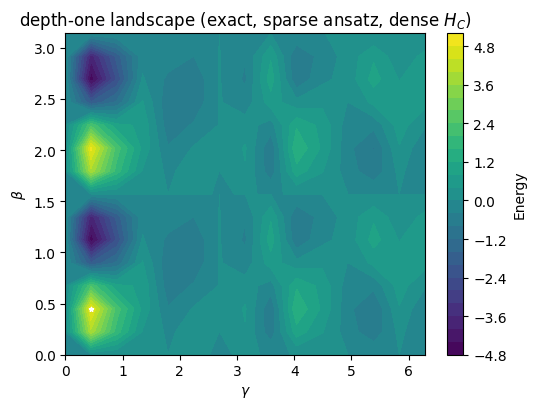

In [47]:
fig, axis = plt.subplots(1, 1, figsize=(5.5, 4.2))
scanner.plot(axis=axis, fig=fig)
axis.set_title("depth-one landscape (exact, sparse ansatz, dense $H_C$)")
fig.tight_layout()
plt.show()

## Check that the exact contraction matches EfficientDepthOneEvaluator to simulator precision

In [ ]:
check_graph = weighted_complete_graph(8, seed=7)
check_cost_op = graph_to_operator(check_graph)
swap_strategy = SwapStrategy.from_line(list(range(8)))
check_ansatz = generate_subgraph_swap_distance(swap_strategy, check_graph, 8)
check_angles = [0.35, 0.62]

exact_energy = EfficientDepthOneEvaluator().evaluate(
    check_cost_op, check_angles, ansatz_circuit=ansatz_circuit(check_ansatz)
)
contracted = make_contraction_evaluator(bond_dim=256).evaluate(
    check_cost_op, check_angles, ansatz_circuit=ansatz_operator(check_ansatz)
)
sampled = make_sample_evaluator(bond_dim=256, shots=200_000).evaluate(
    check_cost_op, check_angles, ansatz_circuit=ansatz_operator(check_ansatz)
)

print(f"EfficientDepthOneEvaluator : {exact_energy:.10f}")
print(
    f"contraction                : {contracted:.10f}   (diff {abs(contracted - exact_energy):.2e})"
)
print(f"MPSSampleEvaluator         : {sampled:.10f}   (diff {abs(sampled - exact_energy):.2e})")

repeats = [
    make_contraction_evaluator(bond_dim=256).evaluate(
        check_cost_op, check_angles, ansatz_circuit=ansatz_operator(check_ansatz)
    )
    for _ in range(3)
]
print(f"\ncontraction repeated 3x, spread: {np.std(repeats):.2e}")

assert abs(contracted - exact_energy) < 1e-8, "the contraction is not exact"
assert abs(sampled - exact_energy) < 0.05, "MPSSampleEvaluator disagrees with the exact result"

EfficientDepthOneEvaluator : 1.0682409912
contraction                : 1.0682409912   (diff 3.33e-15)
MPSSampleEvaluator         : 1.0523586641   (diff 1.59e-02)

contraction repeated 3x, spread: 0.00e+00


## Benchmarking methods 
Define the methods that give the expected values derived from contraction and sampling, timed. 

In [51]:
def timed(func, *args, repeats=REPEATS, **kwargs):
    """Warm up once, then time `repeats` calls. Returns (values, times)."""
    func(*args, **kwargs)

    values, times = [], []
    for _ in range(repeats):
        start = perf_counter()
        values.append(float(np.real(func(*args, **kwargs))))
        times.append(perf_counter() - start)

    return np.array(values), np.array(times)


def head_to_head(operator, sub_graph, params, bond_dim=BOND_DIM, shots=SHOTS, repeats=REPEATS):
    """Accuracy and evaluation time of contraction and sampling against the exact reference."""
    circuit, ansatz_op = ansatz_circuit(sub_graph), ansatz_operator(sub_graph)

    exact_values, exact_times = timed(
        EfficientDepthOneEvaluator().evaluate,
        operator,
        params,
        ansatz_circuit=circuit,
        repeats=repeats,
    )
    reference = float(exact_values[0])

    contraction = make_contraction_evaluator(bond_dim=bond_dim)
    contracted_values, contracted_times = timed(
        contraction.evaluate, operator, params, ansatz_circuit=ansatz_op, repeats=repeats
    )

    sampler = make_sample_evaluator(bond_dim=bond_dim, shots=shots)
    sampled_values, sampled_times = timed(
        sampler.evaluate, operator, params, ansatz_circuit=ansatz_op, repeats=repeats
    )

    per_sample = np.array(sampler.energies(sampler.get_results_from_last_iteration()["counts"]))
    shot_noise = float(per_sample.std() / np.sqrt(shots))

    return {
        "ansatz_edges": sub_graph.number_of_edges(),
        "cost_terms": len(operator),
        "reference": reference,
        "exact_time": float(np.median(exact_times)),
        "contraction_energy": float(contracted_values.mean()),
        "contraction_error": float(np.abs(contracted_values - reference).mean()),
        "contraction_time": float(np.median(contracted_times)),
        "sampler_energy": float(sampled_values.mean()),
        "sampler_error": float(np.abs(sampled_values - reference).mean()),
        "sampler_spread": float(sampled_values.std()),
        "sampler_time": float(np.median(sampled_times)),
        "shot_noise": shot_noise,
    }

### Print small summary of a test benchmarking run

In [52]:
main = head_to_head(cost_op, ansatz_graph, angles)

print(
    f"n = {NUM_QUBITS} qubits, {main['cost_terms']} cost terms, "
    f"{main['ansatz_edges']} ansatz edges, chi = {BOND_DIM}, shots = {SHOTS}"
)
print(f"angles from the scan: beta = {beta:.4f}, gamma = {gamma:.4f}")
print()
print(f"{'evaluator':<28}{'energy':>12}{'abs. error':>13}{'time [s]':>11}")
print("-" * 64)
print(
    f"{'EfficientDepthOne (exact)':<28}{main['reference']:>12.5f}{'-':>13}"
    f"{main['exact_time']:>11.4f}"
)
print(
    f"{'contraction':<28}{main['contraction_energy']:>12.5f}"
    f"{main['contraction_error']:>13.2e}{main['contraction_time']:>11.4f}"
)
print(
    f"{'MPSSampleEvaluator':<28}{main['sampler_energy']:>12.5f}"
    f"{main['sampler_error']:>13.2e}{main['sampler_time']:>11.4f}"
)
print()
print(f"sampler spread over {REPEATS} repetitions:   {main['sampler_spread']:.3e}")
print(f"shot-noise floor sigma_E/sqrt(shots): {main['shot_noise']:.3e}")
print(
    f"time ratio sampler/contraction:       {main['sampler_time'] / main['contraction_time']:.2f}"
)

n = 16 qubits, 120 cost terms, 22 ansatz edges, chi = 64, shots = 4000
angles from the scan: beta = 0.4488, gamma = 0.4488

evaluator                         energy   abs. error   time [s]
----------------------------------------------------------------
EfficientDepthOne (exact)        4.90998            -     0.0117
contraction                      4.90900     9.86e-04     1.2094
MPSSampleEvaluator               4.94805     1.52e-01     0.5616

sampler spread over 4 repetitions:   1.591e-01
shot-noise floor sigma_E/sqrt(shots): 1.444e-01
time ratio sampler/contraction:       0.46


## Benchmark both approaches for increasing number of qubits


In [ ]:
sizes = [8, 12, 16, 20, 24, 28, 32, 36, 40]
scaling_rows = []


for num_qubits in sizes:
    graph = weighted_complete_graph(num_qubits, seed=SEED)
    operator = graph_to_operator(graph)

    swap_strategy = SwapStrategy.from_line(list(range(num_qubits)))
    sub_graph = generate_subgraph_swap_distance(swap_strategy, graph, num_qubits / 10)

    size_angles, _, _ = scan_angles(operator, sub_graph, num_points=SWEEP_SCAN_POINTS)
    row = head_to_head(
        operator,
        sub_graph,
        size_angles,
        bond_dim=SWEEP_BOND_DIM,
        shots=SWEEP_SHOTS,
        repeats=2,
    )
    row["num_qubits"] = num_qubits
    scaling_rows.append(row)

    print(
        f"n={num_qubits:3d}  terms={row['cost_terms']:5d}  ansatz={row['ansatz_edges']:4d}  "
        f"contraction: {row['contraction_time']:7.3f} s / err {row['contraction_error']:.2e}   "
        f"sampler: {row['sampler_time']:7.3f} s / err {row['sampler_error']:.2e}   "
        f"ratio {row['sampler_time'] / row['contraction_time']:.2f}"
    )

n=  8  terms=   28  ansatz=   7  contraction:   0.003 s / err 2.89e-15   sampler:   0.028 s / err 8.23e-02   ratio 8.76
n= 12  terms=   66  ansatz=  16  contraction:   0.054 s / err 2.48e-02   sampler:   0.124 s / err 4.86e-02   ratio 2.29
n= 16  terms=  120  ansatz=  22  contraction:   0.224 s / err 5.94e-02   sampler:   0.295 s / err 1.47e-01   ratio 1.32
n= 20  terms=  190  ansatz=  38  contraction:   0.476 s / err 2.60e-01   sampler:   0.463 s / err 2.08e-01   ratio 0.97
n= 24  terms=  276  ansatz=  46  contraction:   0.973 s / err 1.59e-01   sampler:   0.655 s / err 2.04e-01   ratio 0.67
n= 28  terms=  378  ansatz=  54  contraction:   1.649 s / err 1.47e+00   sampler:   0.882 s / err 1.31e+00   ratio 0.54
n= 32  terms=  496  ansatz=  77  contraction:   2.631 s / err 1.72e-01   sampler:   1.178 s / err 6.46e-02   ratio 0.45
n= 36  terms=  630  ansatz=  87  contraction:   4.213 s / err 1.22e+00   sampler:   1.480 s / err 4.78e-01   ratio 0.35
n= 40  terms=  780  ansatz= 117  contrac

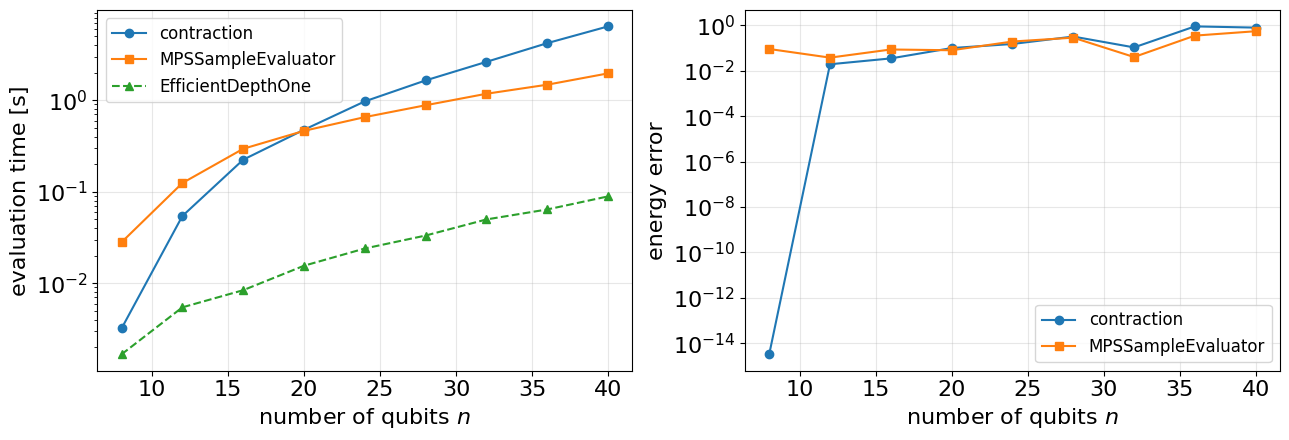

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
qubit_counts = [row["num_qubits"] for row in scaling_rows]

axes[0].plot(
    qubit_counts, [row["contraction_time"] for row in scaling_rows], "o-", label="contraction"
)
axes[0].plot(
    qubit_counts, [row["sampler_time"] for row in scaling_rows], "s-", label="MPSSampleEvaluator"
)
axes[0].plot(
    qubit_counts, [row["exact_time"] for row in scaling_rows], "^--", label="EfficientDepthOne"
)
axes[0].set_yscale("log")
axes[0].set_ylabel("evaluation time [s]", fontsize=16)
axes[0].legend(fontsize=12)

# ratios = [row["sampler_time"] / row["contraction_time"] for row in scaling_rows]
# axes[1].plot(qubit_counts, ratios, "d-", color="tab:red")
# axes[1].axhline(1.0, color="k", lw=1, ls="--")
# axes[1].set_yscale("log")
# axes[1].set_ylabel("time ratio  sampler / contraction")
# axes[1].set_title("below 1: sampling is cheaper")

axes[1].plot(
    qubit_counts,
    [max(row["contraction_error"] / row["reference"], 1e-16) for row in scaling_rows],
    "o-",
    label="contraction",
)
axes[1].plot(
    qubit_counts,
    [row["sampler_error"] / row["reference"] for row in scaling_rows],
    "s-",
    label="MPSSampleEvaluator",
)
# axes[1].plot(
#     qubit_counts,
#     [row["shot_noise"] / row["reference"] for row in scaling_rows],
#     "k--",
#     lw=1,
#     label=r"$\sigma_E/\sqrt{\mathrm{shots}}$",
# )
axes[1].set_yscale("log")
axes[1].set_ylabel("energy error", fontsize=16)
axes[1].legend(fontsize=12)

for axis in axes:
    axis.set_xlabel("number of qubits $n$", fontsize=16)
    axis.grid(alpha=0.3)
    axis.tick_params(axis="both", labelsize=16)

# fig.suptitle(
#     f"dense $H_C$, ansatz of mean degree {MEAN_DEGREE}, "
#     f"$\\chi$ = {SWEEP_BOND_DIM}, {SWEEP_SHOTS} shots"
# )
fig.tight_layout()
plt.show()